# **CANCER**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.feature_selection import RFECV
from xgboost import cv, DMatrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
import numpy as np
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


## **EDA**

In [2]:
data = pd.read_csv("../Data/survey lung cancer.csv")
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


### Encode Categorical Variable

In [3]:
from sklearn.preprocessing import LabelEncoder

# Misalkan kolom 'gender' adalah kolom kategorikal
label_encoder = LabelEncoder()
data['GENDER'] = label_encoder.fit_transform(data['GENDER'])
data['LUNG_CANCER'] = label_encoder.fit_transform(data['LUNG_CANCER'])


In [4]:
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int32
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
GENDER,309.0,0.524272,0.500221,0.0,0.0,1.0,1.0,1.0
AGE,309.0,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SMOKING,309.0,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,309.0,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
ANXIETY,309.0,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,309.0,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,309.0,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FATIGUE,309.0,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
ALLERGY,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WHEEZING,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0


In [27]:
data.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [28]:
data.duplicated().sum()

33

In [4]:
data = data.drop_duplicates()

In [5]:
data.duplicated().sum()

0

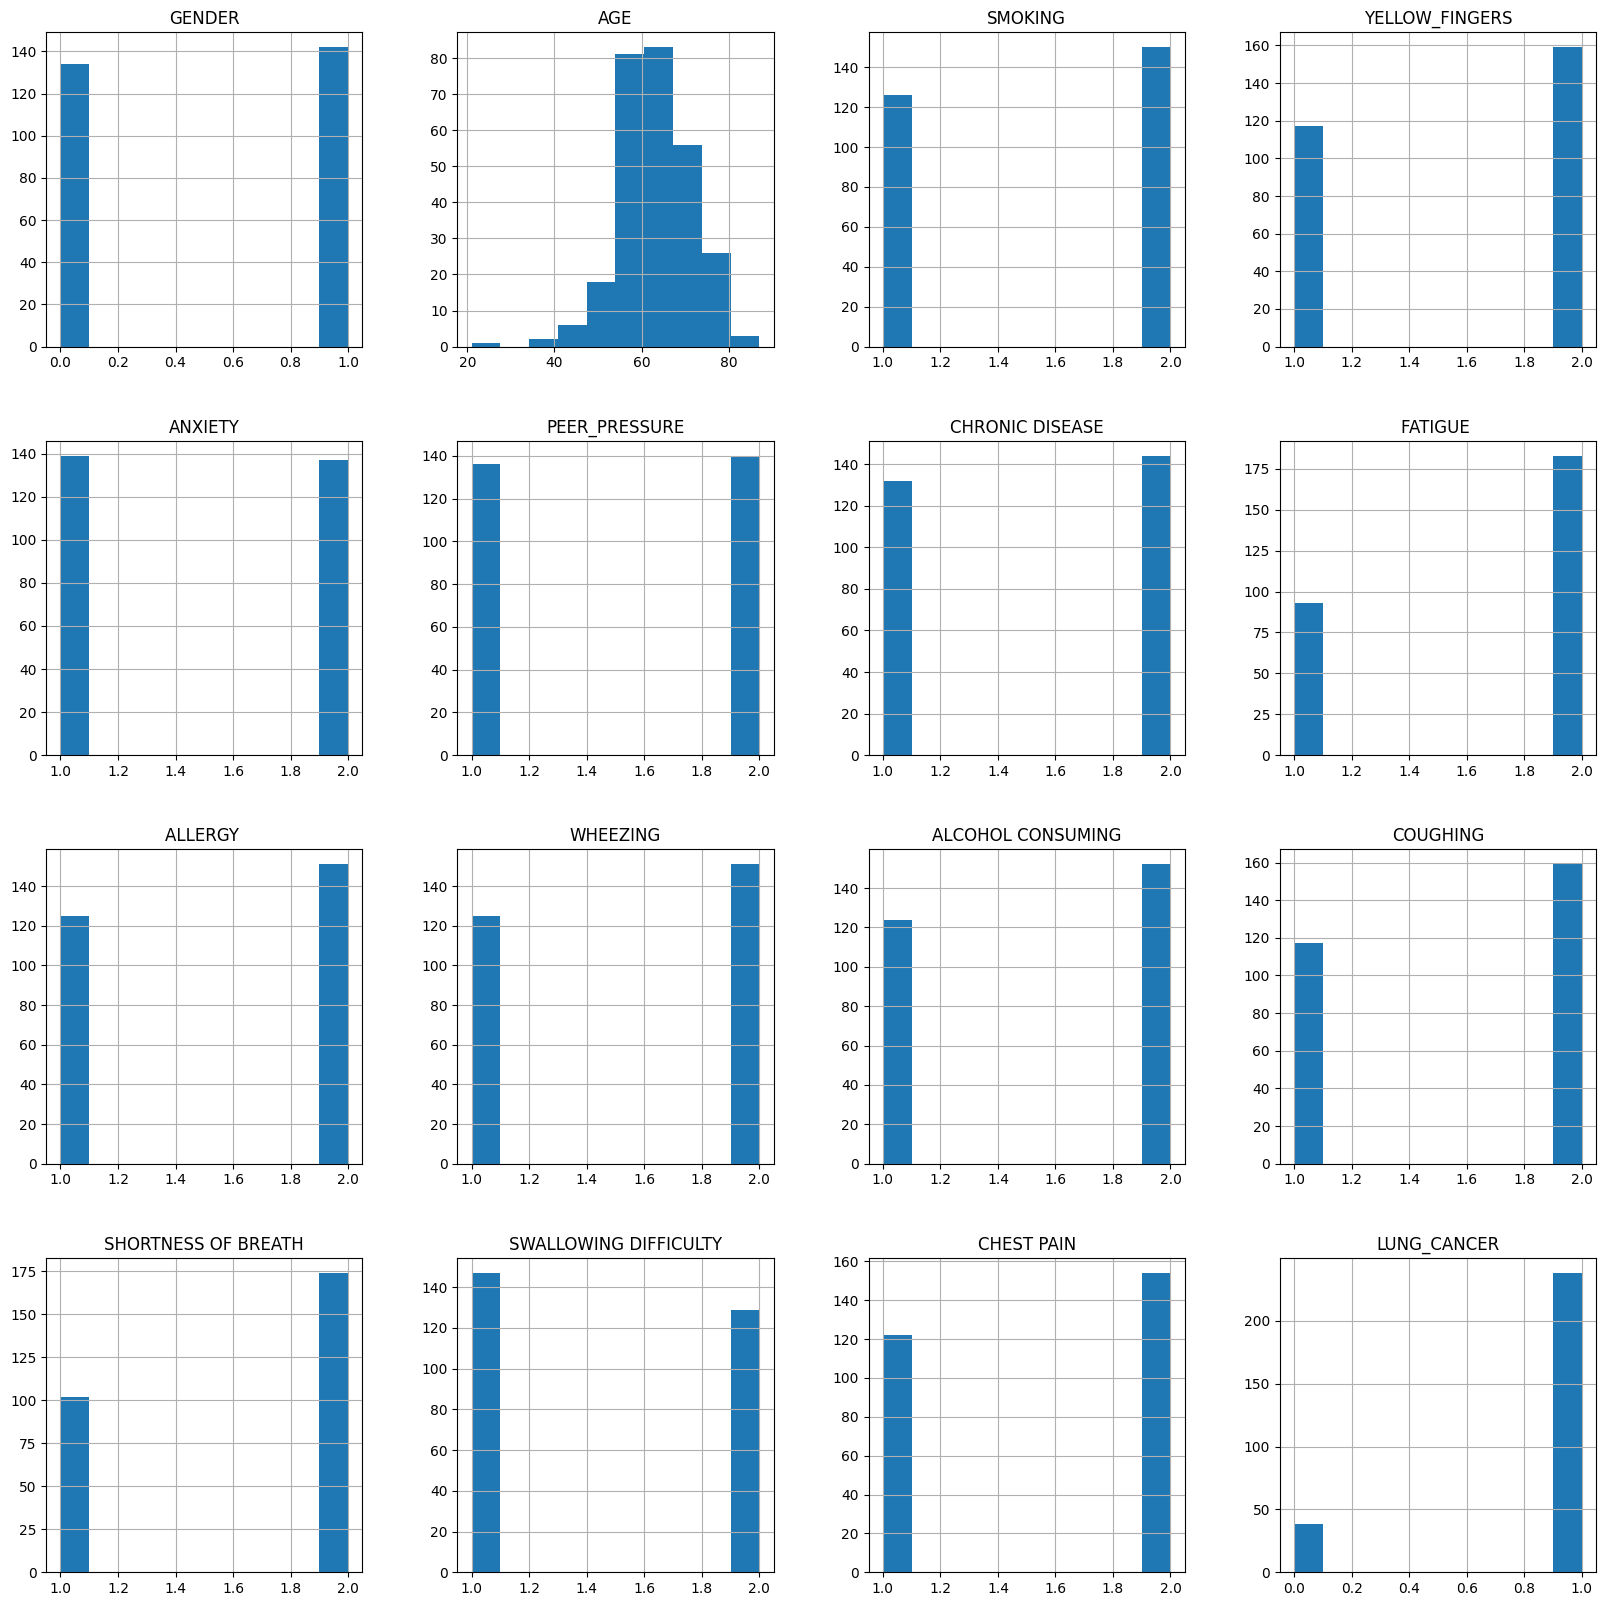

In [31]:
data.hist(figsize=(20,20))
plt.show()

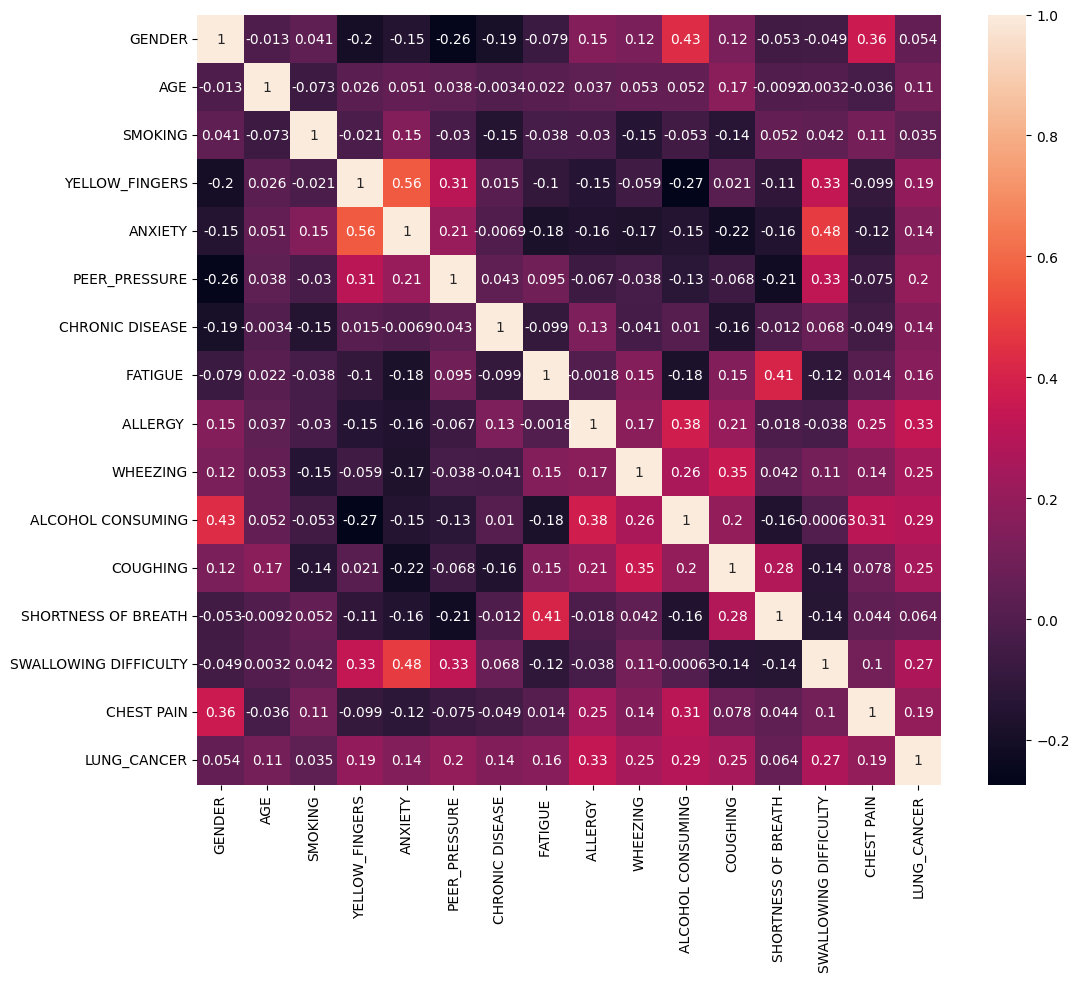

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=[12,10])
sns.heatmap(data.corr(), annot= True)
plt.show()

### FEATURE IMPORTANCE

In [5]:
# Load dataset
# Gantilah dengan data Anda sendiri
X = data.drop(columns=['LUNG_CANCER'])
y = data['LUNG_CANCER']

Mean Squared Error: 0.019790619495378553
Feature 0: 0.03202558308839798
Feature 1: 0.02822699584066868
Feature 2: 0.023012395948171616
Feature 3: 0.08388451486825943
Feature 4: 0.06411515176296234
Feature 5: 0.03125718981027603
Feature 6: 0.04713764414191246
Feature 7: 0.12147758901119232
Feature 8: 0.10649731755256653
Feature 9: 0.011153938248753548
Feature 10: 0.10988196730613708
Feature 11: 0.07378017902374268
Feature 12: 0.045548319816589355
Feature 13: 0.17121534049510956
Feature 14: 0.05078589916229248


<Figure size 1000x800 with 0 Axes>

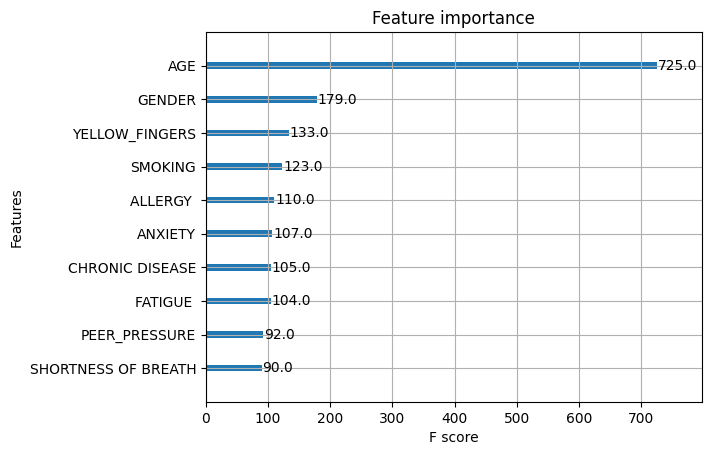

In [6]:
# Bagi dataset menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi dan latih model XGBoost
model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
model.fit(X_train, y_train)

# Lakukan prediksi (opsional, untuk mengevaluasi model)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Tampilkan feature importance
importance = model.feature_importances_
for i, v in enumerate(importance):
    print(f"Feature {i}: {v}")

# Visualisasi feature importance
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=10, importance_type='weight')  # Ubah importance_type sesuai kebutuhan
plt.show()


### FEATURE SELECTION
- berdasarkan performa ROC AUC

In [7]:
def analyze_feature_combinations(model, X_train, X_val, y_train, y_val, feature_names):
    """
    Analyze model performance with different feature combinations based on ROC AUC.
    """
    print("\n" + "="*50)
    print("FEATURE SELECTION ANALYSIS")
    print("="*50)
    
    # Tentukan fitur yang dikategorikan berdasarkan nama fitur
    gender_features = [f for f in feature_names if f.startswith('GENDER')]
    age_features = [f for f in feature_names if f.startswith('AGE')]
    smoking_features = [f for f in feature_names if f.startswith('SMOKING')]
    yellowfingers_features = [f for f in feature_names if f.startswith('YELLOW_FINGERS')]
    anxiety_features = [f for f in feature_names if f.startswith('ANXIETY')]
    peerpressure_features = [f for f in feature_names if f.startswith('PEER_PRESSURE')]
    chronic_desease_features = [f for f in feature_names if f.startswith('CHRONIC DISEASE')]
    fatigue_features = [f for f in feature_names if f.startswith('FATIGUE')]
    allergy_features = [f for f in feature_names if f.startswith('ALLERGY')]
    whezzing_features = [f for f in feature_names if f.startswith('WHEEZING')]
    alcohol_features = [f for f in feature_names if f.startswith('ALCOHOL CONSUMING')]
    coughing_features = [f for f in feature_names if f.startswith('COUGHING')]
    shortnessofbreath_features = [f for f in feature_names if f.startswith('SHORTNESS OF BREATH')]
    swallowing_features = [f for f in feature_names if f.startswith('SWALLOWING DIFFICULTY')]
    chestpain_features = [f for f in feature_names if f.startswith('CHEST PAIN')]

    # Gabungkan fitur berdasarkan urutan penting atau kategori yang relevan
    ordered_features = (
        gender_features +
        age_features +
        smoking_features +
        yellowfingers_features +
        anxiety_features +
        peerpressure_features +
        chronic_desease_features +
        fatigue_features +
        allergy_features +
        whezzing_features +
        alcohol_features +
        coughing_features +
        shortnessofbreath_features +
        swallowing_features +
        chestpain_features
    )

    # Definisikan kombinasi fitur untuk diuji
    feature_sets = {
        'Set with 3 Features': ordered_features[:3],
        'Set with 4 Features': ordered_features[:4],
        'Set with 5 Features': ordered_features[:5],
        'Set with 8 Features': ordered_features[:8],
        'Set with 9 Features': ordered_features[:9],
        'All Features': ordered_features
    }
    
    results = []
    
    # Loop untuk setiap set fitur
    for set_name, features in feature_sets.items():
        print(f"\nEvaluating {set_name} with features: {features}")
        
        # Pilih subset fitur untuk train dan validation
        X_train_subset = X_train[features]
        X_val_subset = X_val[features]
        
        # Latih model dengan subset fitur
        model.fit(X_train_subset, y_train)
        
        # Prediksi probabilitas untuk ROC AUC
        y_pred_proba = model.predict_proba(X_val_subset)[:, 1]
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        
        print(f"ROC AUC for {set_name}: {roc_auc}")
        
        # Simpan hasil untuk analisis
        results.append((set_name, roc_auc))
    
    # Tampilkan hasil akhir
    print("\nFeature Selection Results:")
    for set_name, roc_auc in results:
        print(f"{set_name}: ROC AUC = {roc_auc}")

# Contoh penggunaan
# Pisahkan data training dan validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model XGBoost
model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

# Dapatkan nama fitur dari dataset
feature_names = X.columns  # Asumsikan X adalah DataFrame

# Panggil fungsi untuk menganalisis kombinasi fitur
analyze_feature_combinations(model, X_train, X_val, y_train, y_val, feature_names)


FEATURE SELECTION ANALYSIS

Evaluating Set with 3 Features with features: ['GENDER', 'AGE', 'SMOKING']
ROC AUC for Set with 3 Features: 0.8583333333333334

Evaluating Set with 4 Features with features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS']
ROC AUC for Set with 4 Features: 0.6583333333333333

Evaluating Set with 5 Features with features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY']
ROC AUC for Set with 5 Features: 0.5083333333333333

Evaluating Set with 8 Features with features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ']
ROC AUC for Set with 8 Features: 0.825

Evaluating Set with 9 Features with features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ']
ROC AUC for Set with 9 Features: 0.9916666666666667

Evaluating All Features with features: ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE'

## **MODELLING**
- Menggunakan SMOTE 

In [6]:
from sklearn.preprocessing import MinMaxScaler
ms_X = MinMaxScaler()

In [7]:
X = pd.DataFrame(ms_X.fit_transform(data[['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ']]))
y = data['LUNG_CANCER']

In [9]:
import joblib
joblib.dump(ms_X, "./Output_Model/scaler_cancer.pkl")

['./Output_Model/scaler_cancer.pkl']

In [10]:
# bagi data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

### SMOTE

In [11]:
# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Initialize SMOTE for oversampling
smote = SMOTE(random_state=42)
# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### XGBoost

              precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1       0.94      0.92      0.93        48

    accuracy                           0.88        56
   macro avg       0.75      0.77      0.76        56
weighted avg       0.88      0.88      0.88        56

ROC-AUC: 0.9193


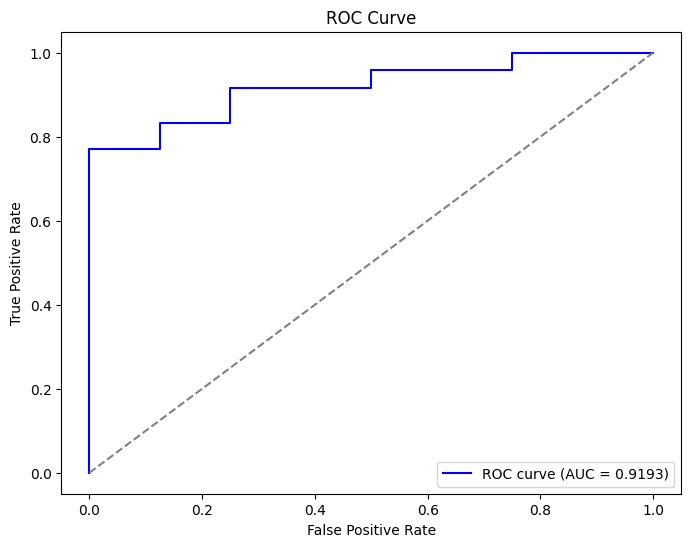

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Set seed untuk konsistensi hasil
seed_value = 42
np.random.seed(seed_value)

# Initialize the XGBoost classifier
xg = XGBClassifier(n_estimators=100)

# Fit the model using resampled data
xg.fit(X_train_resampled, y_train_resampled)

# Make predictions
xg_preds = xg.predict(X_test)
xg_preds_proba = xg.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif

# Print classification report
print(classification_report(y_test, xg_preds))

# Calculate and print ROC-AUC score
roc_auc = roc_auc_score(y_test, xg_preds_proba)
print(f'ROC-AUC: {roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, xg_preds_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


### Random Forest

              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        48

    accuracy                           0.89        56
   macro avg       0.78      0.78      0.78        56
weighted avg       0.89      0.89      0.89        56

ROC-AUC: 0.9375


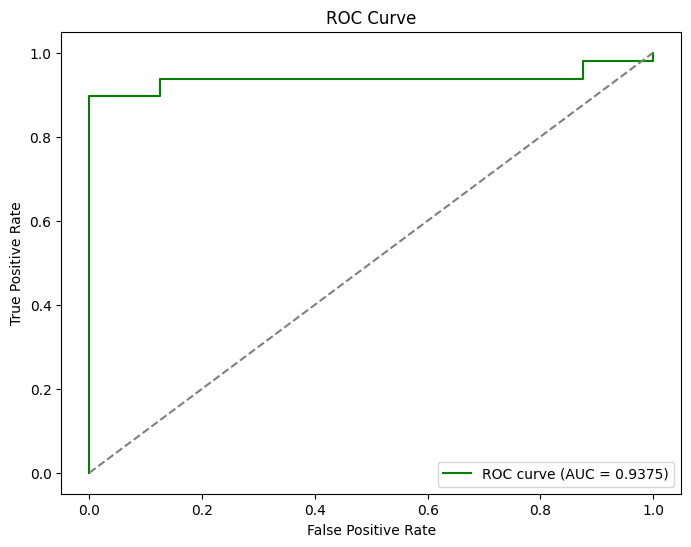

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# Set seed untuk konsistensi hasil
seed_value = 42
np.random.seed(seed_value)

# Initialize the RandomForest classifier
rf = RandomForestClassifier(n_estimators=100)

# Fit the model using resampled data
rf.fit(X_train_resampled, y_train_resampled)

# Make predictions
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif

# Print classification report
print(classification_report(y_test, rf_pred))

# Calculate and print ROC-AUC score
roc_auc = roc_auc_score(y_test, rf_pred_proba)
print(f'ROC-AUC: {roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


### Decision Tree

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         8
           1       0.96      0.92      0.94        48

    accuracy                           0.89        56
   macro avg       0.78      0.83      0.80        56
weighted avg       0.91      0.89      0.90        56

ROC-AUC: 0.8411


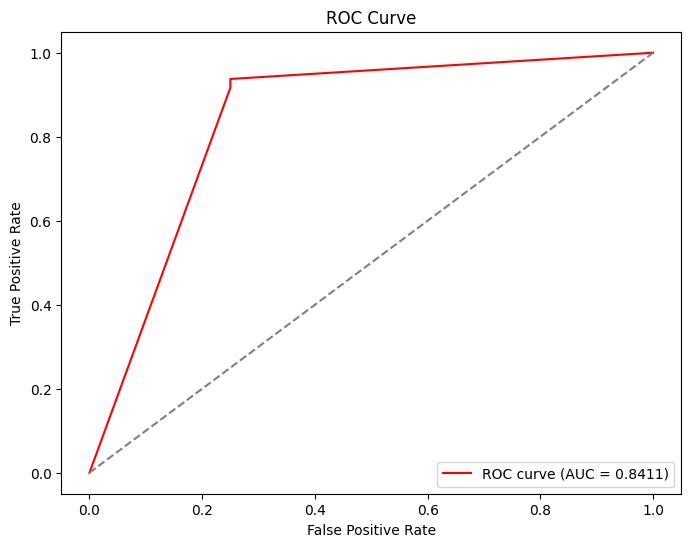

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# Set seed untuk konsistensi hasil
seed_value = 42
np.random.seed(seed_value)
# Membuat model Decision Tree untuk klasifikasi
dt_clf = DecisionTreeClassifier(random_state=42)

# Melatih model
dt_clf.fit(X_train_resampled, y_train_resampled)

# Melakukan prediksi
y_pred = dt_clf.predict(X_test)
y_pred_proba = dt_clf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif

# Menampilkan laporan klasifikasi
print(classification_report(y_test, y_pred))

# Menghitung dan menampilkan skor ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC: {roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


### Cross Validation Random Forest

3-Fold CV ROC-AUC Scores: [0.9656498  0.99305556 0.97329302]
Mean 3-Fold ROC-AUC Score: 0.9773

5-Fold CV ROC-AUC Scores: [0.94044321 0.99861496 0.99099723 0.99445983 0.9684903 ]
Mean 5-Fold ROC-AUC Score: 0.9786

10-Fold CV ROC-AUC Scores: [0.89889197 0.96398892 1.         1.         0.99168975 0.99722992
 0.99445983 1.         0.9833795  0.97922438]
Mean 10-Fold ROC-AUC Score: 0.9809

              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        48

    accuracy                           0.89        56
   macro avg       0.78      0.78      0.78        56
weighted avg       0.89      0.89      0.89        56

ROC-AUC on Test Data: 0.9375


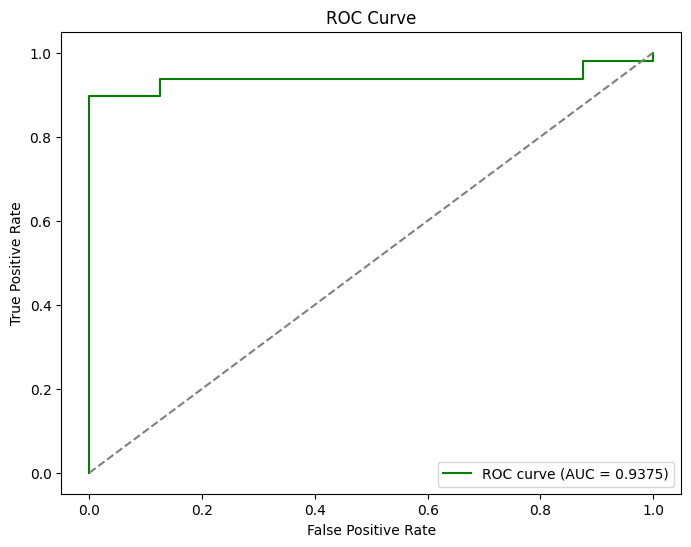

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Set seed untuk konsistensi hasil
seed_value = 42
np.random.seed(seed_value)

# Initialize the RandomForest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=seed_value)

# Define scoring metrics for cross-validation
scoring = {'roc_auc': 'roc_auc'}

# Perform 3-fold cross-validation
cv_results_3 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=3, scoring=scoring)
print("3-Fold CV ROC-AUC Scores:", cv_results_3['test_roc_auc'])
print(f"Mean 3-Fold ROC-AUC Score: {np.mean(cv_results_3['test_roc_auc']):.4f}\n")

# Perform 5-fold cross-validation
cv_results_5 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=5, scoring=scoring)
print("5-Fold CV ROC-AUC Scores:", cv_results_5['test_roc_auc'])
print(f"Mean 5-Fold ROC-AUC Score: {np.mean(cv_results_5['test_roc_auc']):.4f}\n")

# Perform 10-fold cross-validation
cv_results_10 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=10, scoring=scoring)
print("10-Fold CV ROC-AUC Scores:", cv_results_10['test_roc_auc'])
print(f"Mean 10-Fold ROC-AUC Score: {np.mean(cv_results_10['test_roc_auc']):.4f}\n")

# Fit the model on the entire training set after cross-validation for further evaluation
rf.fit(X_train_resampled, y_train_resampled)

# Make predictions
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif

# Print classification report
print(classification_report(y_test, rf_pred))

# Calculate and print ROC-AUC score
roc_auc = roc_auc_score(y_test, rf_pred_proba)
print(f'ROC-AUC on Test Data: {roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib  # Untuk menyimpan model

# Set seed untuk konsistensi hasil
seed_value = 42
np.random.seed(seed_value)

# Initialize the RandomForest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=seed_value)

# Define scoring metrics for cross-validation
scoring = {'roc_auc': 'roc_auc'}

# Perform cross-validation for 3, 5, and 10 folds and calculate the mean ROC-AUC score
cv_results_3 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=3, scoring=scoring)
cv_results_5 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=5, scoring=scoring)
cv_results_10 = cross_validate(rf, X_train_resampled, y_train_resampled, cv=10, scoring=scoring)

# Calculate the mean ROC-AUC score for each CV
mean_roc_auc_3 = np.mean(cv_results_3['test_roc_auc'])
mean_roc_auc_5 = np.mean(cv_results_5['test_roc_auc'])
mean_roc_auc_10 = np.mean(cv_results_10['test_roc_auc'])

# Find the best AUC score and corresponding fold
best_auc = max(mean_roc_auc_3, mean_roc_auc_5, mean_roc_auc_10)
best_cv = 3 if best_auc == mean_roc_auc_3 else (5 if best_auc == mean_roc_auc_5 else 10)

print(f"Best CV fold: {best_cv}-fold with Mean ROC-AUC: {best_auc:.4f}")

Best CV fold: 10-fold with Mean ROC-AUC: 0.9809


In [21]:

# Re-train the model on the entire training set
rf.fit(X_train_resampled, y_train_resampled)

# Make predictions
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif

# Print classification report
print(classification_report(y_test, rf_pred))

# Calculate and print ROC-AUC score
roc_auc = roc_auc_score(y_test, rf_pred_proba)
print(f'ROC-AUC on Test Data: {roc_auc:.4f}')


              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        48

    accuracy                           0.89        56
   macro avg       0.78      0.78      0.78        56
weighted avg       0.89      0.89      0.89        56

ROC-AUC on Test Data: 0.9375


## Confusion Matrix

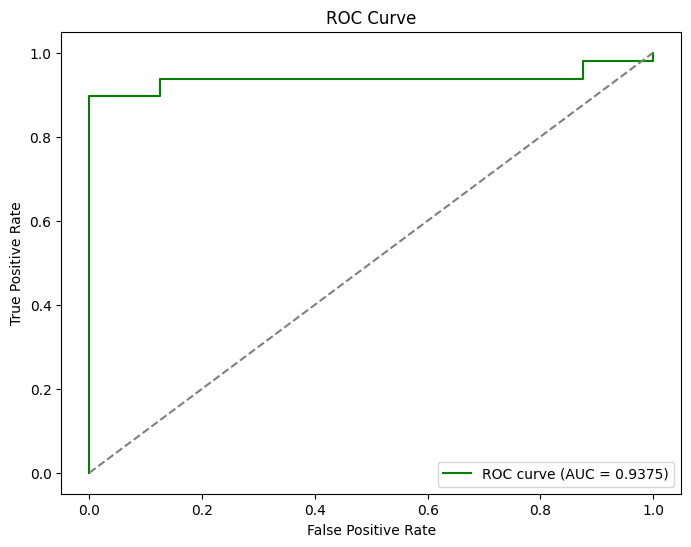

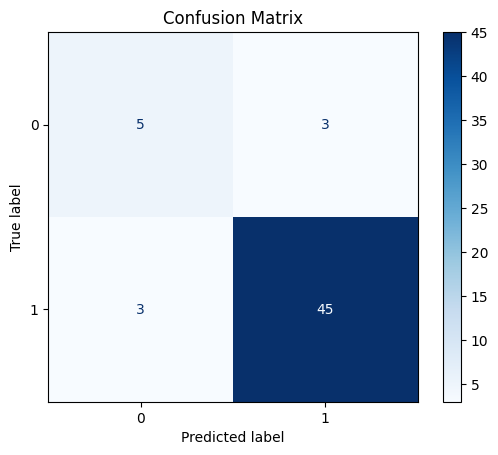

In [22]:

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


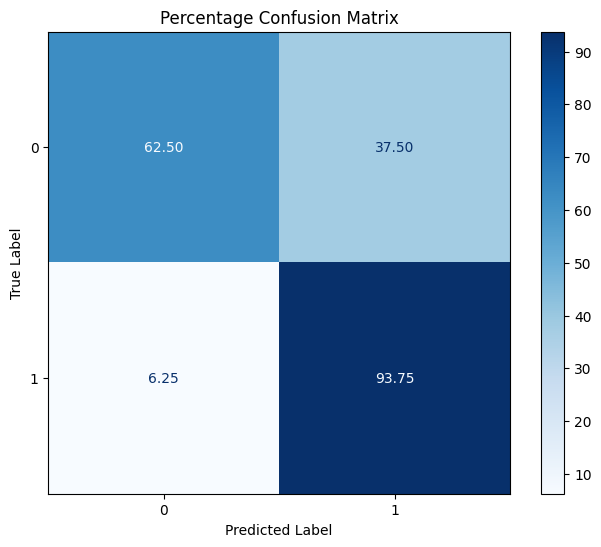

In [23]:
# Generate confusion matrix dan konversi ke persentase
cm = confusion_matrix(y_test, rf_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentages
# Plot the percentage confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
disp.plot(cmap='Blues', ax=ax, values_format=".2f")
plt.title('Percentage Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## EKSPOR MODEL

In [ ]:
# Export the trained model
joblib.dump(rf, 'best_rf_model.pkl')
print("Model saved as 'best_rf_model.pkl'")


In [25]:
import joblib
import pickle

# Tentukan path dan nama file untuk menyimpan model
model_path = "./Output_Model/cancer.pkl"

# Simpan model
joblib.dump(rf, model_path)
print(f"Model saved to {model_path}")

Model saved to ./Output_Model/cancer.pkl


### Create example data for prediction

In [26]:
import pandas as pd
data_test = pd.read_csv(r"D:\Lomba-Lomba\TSDN 2024\cancerno xxx.csv")
data_test.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY '],
      dtype='object')

In [27]:
import joblib
# Memuat model yang disimpan (sesuaikan nama file model)
model_path = "./Output_Model/cancer.pkl" # Sesuaikan path model
model = joblib.load(model_path)

scaler_path = "./Output_Model/scaler_cancer.pkl"
ms_X = joblib.load(scaler_path)
data_test = (ms_X.transform(data_test))

In [28]:
# Melakukan prediksi
predictions = model.predict(data_test)

# Menampilkan atau menyimpan hasil prediksi
print(predictions)
pd.DataFrame(predictions, columns=['Predictions']).to_csv("predictions.csv", index=False)
print("Prediksi telah disimpan ke predictions.csv")

[1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 1 0 1 0 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
Prediksi telah disimpan ke predictions.csv


In [20]:
import sklearn
from sklearn.tree import DecisionTreeClassifier

# Menampilkan versi scikit-learn yang terinstal
print("Versi scikit-learn:", sklearn.__version__)

Versi scikit-learn: 1.3.2


In [23]:
import joblib
joblib.__version__

'1.3.1'

In [21]:
# Cek versi DecisionTreeClassifier
print("Versi DecisionTreeClassifier:", DecisionTreeClassifier.__module__)

Versi DecisionTreeClassifier: sklearn.tree._classes
